# TSF vs CPS vs TSCQR vs MSCP — dados discretos reais

Comparação entre **TSF**, **CPS**, **TSCQR** e **MSCP** em M5 e UCI Bike Sharing. Todos são avaliados fora da amostra, com alvos inteiros e sem dados sintéticos.

In [5]:
from importlib.metadata import version
from pathlib import Path
from time import perf_counter
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMRegressor
from mlforecast import MLForecast
from sklearn.ensemble import HistGradientBoostingRegressor

from tinyshift.forecasting import (
    NegativeBinomialFamily,
    TwoStageForecasterWrapper,
    WeibullFamily,
)
from tinyconformal.series import (
    ConformalDistributionTimeSeriesRegressor,
    ConformalQuantileTimeSeriesRegressor,
    ContinuousTimeSeriesConformalPredictiveSystem,
    DiscreteTimeSeriesConformalPredictiveSystem,
)

SEED = 42
H = 14
N_WINDOWS = 12
LEVEL = 0.90
DATA_DIR = Path("data/tsf_cps")
DATA_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")

print({"tinyshift": version("tinyshift"), "tinyconformal": version("tinyconformal")})

{'tinyshift': '1.9.3', 'tinyconformal': '0.5.4'}


In [6]:
def make_forecaster(freq, lags):
    model = LGBMRegressor(
        n_estimators=120, learning_rate=0.05, num_leaves=15,
        verbosity=-1, random_state=SEED, n_jobs=1,
    )
    return MLForecast(models={"LGBM": model}, freq=freq, lags=lags)


def make_quantile_forecaster(freq, lags, level=LEVEL):
    alpha = 1-level
    models = {
        "LGBM": LGBMRegressor(
            n_estimators=120, learning_rate=0.05, num_leaves=15,
            verbosity=-1, random_state=SEED, n_jobs=1,
        ),
        "LGBM-lo-90": LGBMRegressor(
            objective="quantile", alpha=alpha/2, n_estimators=120,
            learning_rate=0.05, num_leaves=15, verbosity=-1,
            random_state=SEED, n_jobs=1,
        ),
        "LGBM-hi-90": LGBMRegressor(
            objective="quantile", alpha=1-alpha/2, n_estimators=120,
            learning_rate=0.05, num_leaves=15, verbosity=-1,
            random_state=SEED, n_jobs=1,
        ),
    }
    return MLForecast(models=models, freq=freq, lags=lags)


def fit_tsf(
    train, freq, lags, family, nexcp, weighted_refit,
    h=H, n_windows=N_WINDOWS, step_size=None, decay=0.99,
):
    model = TwoStageForecasterWrapper(make_forecaster(freq, lags), distribution=family)
    tic = perf_counter()
    model.fit(
        train, horizon=h, n_windows=n_windows, step_size=step_size,
        nexcp=nexcp, decay=decay, weighted_refit=weighted_refit,
    )
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_cps(
    train, freq, lags, discrete, h=H, n_windows=N_WINDOWS, step_size=None
):
    cls = (DiscreteTimeSeriesConformalPredictiveSystem if discrete
           else ContinuousTimeSeriesConformalPredictiveSystem)
    model = cls(
        learner=make_forecaster(freq, lags),
        dispersion_learner=HistGradientBoostingRegressor(
            max_iter=80, max_leaf_nodes=8, random_state=SEED
        ),
        horizon=h, n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_distribution(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_tscqr(train, freq, lags, h=H, n_windows=N_WINDOWS, step_size=None):
    model = ConformalQuantileTimeSeriesRegressor(
        learner=make_quantile_forecaster(freq, lags), horizon=h,
        intervals=("LGBM-lo-90", "LGBM-hi-90"), n_windows=n_windows,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_interval(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def fit_mscp(train, freq, lags, h=H, n_windows=N_WINDOWS, step_size=None):
    model = ConformalDistributionTimeSeriesRegressor(
        learner=make_forecaster(freq, lags), horizon=h,
        n_windows=n_windows, alpha=1-LEVEL,
    )
    tic = perf_counter()
    model.fit(train, step_size=step_size, n_jobs=1)
    fit_seconds = perf_counter() - tic
    tic = perf_counter()
    forecast = model.predict_interval(h=h)
    predict_seconds = perf_counter() - tic
    return model, forecast, fit_seconds, predict_seconds


def prediction_table(forecast, test, level=LEVEL):
    base = forecast.to_frame().copy()
    intervals = forecast.interval(level)
    quantiles = forecast.ppf([0.5])
    out = base.merge(test[["unique_id", "ds", "y"]], on=["unique_id", "ds"], validate="one_to_one")
    # A branch feature/decay usa Q(0.05), Q(0.5), Q(0.95); versões
    # anteriores usavam sufixos -lo-, -q-50 e -hi-. Em ambos os casos,
    # as colunas projetadas são as únicas que não pertencem ao frame-base.
    interval_cols = [c for c in intervals if c not in base.columns]
    median_cols = [c for c in quantiles if c not in base.columns]
    if len(interval_cols) != 2 or len(median_cols) != 1:
        raise ValueError(
            "Formato inesperado do forecast: "
            f"intervalos={interval_cols}, mediana={median_cols}"
        )
    lo_col, hi_col = interval_cols
    median_col = median_cols[0]
    out["lower"] = intervals[lo_col].to_numpy()
    out["upper"] = intervals[hi_col].to_numpy()
    out["median"] = quantiles[median_col].to_numpy()
    return out


def conformal_prediction_table(forecast, test, method):
    out = forecast.merge(
        test[["unique_id", "ds", "y"]],
        on=["unique_id", "ds"], validate="one_to_one",
    )
    if method == "TSCQR":
        out["lower"] = out["LGBM-lo-90-cqr"]
        out["upper"] = out["LGBM-hi-90-cqr"]
        out["median"] = out["LGBM"]
    elif method == "MSCP":
        out["lower"] = out["LGBM-lo-90"]
        out["upper"] = out["LGBM-hi-90"]
        out["median"] = out["LGBM"]
    else:
        raise ValueError(f"Método conformal desconhecido: {method}")
    return out


def metrics(table, method, dataset, fit_seconds, predict_seconds, level=LEVEL):
    y = table.y.to_numpy(float)
    lo, hi, pred = (table[c].to_numpy(float) for c in ["lower", "upper", "median"])
    alpha = 1-level
    covered = (y >= lo) & (y <= hi)
    winkler = (hi-lo) + (2/alpha)*(lo-y)*(y < lo) + (2/alpha)*(y-hi)*(y > hi)
    return {
        "dataset": dataset, "method": method,
        "RMSE_mediana": np.sqrt(np.mean((y-pred)**2)),
        "MAE_mediana": np.mean(np.abs(y-pred)),
        "cobertura_90": covered.mean(), "largura_media_90": np.mean(hi-lo),
        "Winkler_90": np.mean(winkler), "fit_s": fit_seconds,
        "predict_s": predict_seconds, "n_teste": len(y),
    }


def plot_intervals(tables, title):
    fig, axes = plt.subplots(len(tables), 1, figsize=(13, 3.6*len(tables)), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (name, tab) in zip(axes, tables.items()):
        one = tab[tab.unique_id == tab.unique_id.iloc[0]]
        ax.plot(one.ds, one.y, "o-", color="black", label="observado", ms=3)
        ax.plot(one.ds, one["median"], color="C0", label="mediana")
        ax.fill_between(one.ds, one.lower, one.upper, alpha=.25, label="intervalo 90%")
        ax.set_title(name); ax.legend(ncol=3)
    fig.suptitle(title, y=1.01); plt.tight_layout()


def temporal_split(df, h=H):
    df = df.sort_values(["unique_id", "ds"]).reset_index(drop=True)
    test = df.groupby("unique_id", group_keys=False).tail(h)
    train = df.drop(test.index).reset_index(drop=True)
    return train, test.reset_index(drop=True)

In [7]:
M5_URL = "https://www.kaggle.com/competitions/m5-forecasting-accuracy/data"
M5_MIRROR = "https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv"
BIKE_URL = "https://raw.githubusercontent.com/udacity/deep-learning/master/first-neural-network/Bike-Sharing-Dataset/hour.csv"


def load_m5(n_series=5, n_days=700):
    """Baixa a competição oficial (aceite das regras/login Kaggle pode ser necessário)."""
    target = DATA_DIR / "m5" / "sales_train_evaluation.csv"
    if not target.exists():
        import kagglehub
        try:
            downloaded = Path(kagglehub.competition_download("m5-forecasting-accuracy"))
            candidates = list(downloaded.rglob("sales_train_evaluation.csv"))
        except Exception as exc:
            warnings.warn(f"Kaggle indisponível ({type(exc).__name__}); usando espelho público Hugging Face.")
            candidates = []
        source = candidates[0] if candidates else M5_MIRROR
        target.parent.mkdir(parents=True, exist_ok=True)
        if isinstance(source, Path):
            target.write_bytes(source.read_bytes())
        else:
            from urllib.request import urlretrieve
            urlretrieve(source, target)
    wide = pd.read_csv(target, nrows=n_series)
    day_cols = [c for c in wide if c.startswith("d_")][-n_days:]
    long = wide[["id", *day_cols]].melt("id", var_name="day", value_name="y")
    long["ds"] = pd.Timestamp("2011-01-29") + pd.to_timedelta(long.day.str[2:].astype(int)-1, unit="D")
    return long.rename(columns={"id": "unique_id"})[["unique_id", "ds", "y"]].astype({"y": int})


def load_bike():
    raw = pd.read_csv(BIKE_URL)
    raw["ds"] = pd.to_datetime(raw.dteday) + pd.to_timedelta(raw.hr, unit="h")
    # Maior trecho horário contíguo: não preenche nem sintetiza horas ausentes.
    raw = raw.sort_values("ds")
    run = raw.ds.diff().ne(pd.Timedelta(hours=1)).cumsum()
    raw = raw[run.eq(run.value_counts().idxmax())].tail(24*180)
    return pd.DataFrame({"unique_id": "CapitalBikeshare", "ds": raw.ds, "y": raw.cnt.astype(int)})


datasets = {"M5 (5 itens)": load_m5(), "UCI Bike Sharing": load_bike()}
for name, frame in datasets.items():
    print(name, frame.shape, frame.ds.min(), frame.ds.max(), "inteiros:", np.all(frame.y == np.floor(frame.y)))

M5 (5 itens) (3500, 3) 2014-06-23 00:00:00 2016-05-22 00:00:00 inteiros: True
UCI Bike Sharing (4320, 3) 2012-05-02 01:00:00 2012-10-29 00:00:00 inteiros: True


## Benchmark temporal

A última janela é teste; todas as janelas anteriores são treino/calibração. O mesmo LightGBM, lags, horizonte, 12 janelas e sobreposição são usados pelas duas versões do TSF, CPS, TSCQR e MSCP. O TSF é comparado sem ponderação (`nexcp=False`, `weighted_refit=False`) e com decaimento exponencial tanto na calibração quanto nos ajustes do modelo de média (`nexcp=True`, `weighted_refit=True`, `decay=0.99`). `step_size=3` em AirPassengers e `step_size=7` nas demais séries; como ambos são menores que `H=14`, as janelas se sobrepõem.

In [8]:
results, predictions = [], {}
for dataset_name, df in datasets.items():
    freq = "MS" if dataset_name == "AirPassengers" else ("h" if "Bike" in dataset_name else "D")
    lags = [1, 12] if freq == "MS" else ([1, 24, 168] if freq == "h" else [1, 7, 28])
    step_size = 3 if dataset_name == "AirPassengers" else 7
    train, test = temporal_split(df)

    tsf_configs = {
        "TSF (nexcp=False, weighted_refit=False)": {
            "nexcp": False, "weighted_refit": False,
        },
        "TSF (nexcp=True, weighted_refit=True)": {
            "nexcp": True, "weighted_refit": True,
        },
    }
    for method, config in tsf_configs.items():
        tsf, tsf_fc, tsf_fit, tsf_pred = fit_tsf(
            train, freq, lags, NegativeBinomialFamily(), step_size=step_size, **config
        )
        tsf_tab = prediction_table(tsf_fc, test)
        predictions[(dataset_name, method)] = tsf_tab
        results.append(metrics(tsf_tab, method, dataset_name, tsf_fit, tsf_pred))
    cps, cps_fc, cps_fit, cps_pred = fit_cps(
        train, freq, lags, discrete=True, step_size=step_size
    )
    tscqr, tscqr_fc, tscqr_fit, tscqr_pred = fit_tscqr(
        train, freq, lags, step_size=step_size
    )
    mscp, mscp_fc, mscp_fit, mscp_pred = fit_mscp(
        train, freq, lags, step_size=step_size
    )
    cps_tab = prediction_table(cps_fc, test)
    tscqr_tab = conformal_prediction_table(tscqr_fc, test, "TSCQR")
    mscp_tab = conformal_prediction_table(mscp_fc, test, "MSCP")
    predictions[(dataset_name, "CPS")] = cps_tab
    predictions[(dataset_name, "TSCQR")] = tscqr_tab
    predictions[(dataset_name, "MSCP")] = mscp_tab
    results += [
        metrics(cps_tab, "CPS", dataset_name, cps_fit, cps_pred),
        metrics(tscqr_tab, "TSCQR", dataset_name, tscqr_fit, tscqr_pred),
        metrics(mscp_tab, "MSCP", dataset_name, mscp_fit, mscp_pred),
    ]

resultados = pd.DataFrame(results)
display(resultados.round(4))
display(resultados.pivot(index="dataset", columns="method",
                         values=["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90", "fit_s"]).round(4))

/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tinyconformal/series/mscp.py:244: RuntimeWarning: The requested two-sided coverage is not attainable for ConformalDistributionTimeSeriesRegressor with the available calibration sample (n=12); the conformal rank will be clipped to the observed score range.
  return central_conformal_quantile_levels(
/home/heylucasleao/forecasting/.venv/lib/python3.10/site-packages/tinyconformal/series/mscp.py:244: RuntimeWarning: The requested two-sided coverage is not attainable for ConformalDistributionTimeSeriesRegressor with the available calibration sample (n=12); the conformal rank will be clipped to the observed score range.
  return central_conformal_quantile_levels(


,dataset,method,RMSE_mediana,MAE_mediana,cobertura_90,largura_media_90,Winkler_90,fit_s,predict_s,n_teste
0,M5 (5 itens),"TSF (nexcp=False, weighted_refit=False)",1.3093,0.9429,1.0000,4.1714,4.1714,0.9164,0.0274,70
1,M5 (5 itens),"TSF (nexcp=True, weighted_refit=True)",1.2536,0.9143,1.0000,4.8571,4.8571,1.0253,0.0267,70
2,M5 (5 itens),CPS,1.3990,1.1286,0.8286,3.8000,7.5143,1.7824,0.0336,70
3,M5 (5 itens),TSCQR,1.1933,0.9703,1.0000,5.2058,5.2058,1.8669,0.0739,70
4,M5 (5 itens),MSCP,1.1933,0.9703,0.8000,3.6657,5.0872,0.6753,0.0266,70
5,UCI Bike Sharing,"TSF (nexcp=False, weighted_refit=False)",203.8932,184.8571,0.1429,315.0000,1497.8571,0.7583,0.0239,14
6,UCI Bike Sharing,"TSF (nexcp=True, weighted_refit=True)",191.0142,172.1429,0.3571,310.2143,1398.7857,0.8622,0.0260,14
7,UCI Bike Sharing,CPS,216.5243,198.0714,0.2857,308.9286,2391.7857,1.3849,0.0275,14
8,UCI Bike Sharing,TSCQR,211.9471,192.4657,0.5714,502.9098,613.4769,2.2294,0.0784,14
9,UCI Bike Sharing,MSCP,211.9471,192.4657,0.2857,254.2773,2474.9775,0.7987,0.0255,14


RMSE_mediana                      \
method                    CPS      MSCP     TSCQR   
dataset                                             
M5 (5 itens)           1.3990    1.1933    1.1933   
UCI Bike Sharing     216.5243  211.9471  211.9471   

                                                          \
method           TSF (nexcp=False, weighted_refit=False)   
dataset                                                    
M5 (5 itens)                                      1.3093   
UCI Bike Sharing                                203.8932   

                                                       cobertura_90          \
method           TSF (nexcp=True, weighted_refit=True)          CPS    MSCP   
dataset                                                                       
M5 (5 itens)                                    1.2536       0.8286  0.8000   
UCI Bike Sharing                              191.0142       0.2857  0.2857   

                                                                  \
method             TSCQR TSF (nexcp=False, weighted_refit=False)   
dataset                                                            
M5 (5 itens)      1.0000                                  1.0000   
UCI Bike Sharing  0.5714                                  0.1429   

                                                        ... Winkler_90  \
method           TSF (nexcp=True, weighted_refit=True)  ...        CPS   
dataset                                                 ...              
M5 (5 itens)                                    1.0000  ...     7.5143   
UCI Bike Sharing                                0.3571  ...  2391.7857   

                                                                               \
method                 MSCP     TSCQR TSF (nexcp=False, weighted_refit=False)   
dataset                                                                         
M5 (5 itens)         5.0872    5.2058                                  4.1714   
UCI Bike Sharing  2474.9775  613.4769                               1497.8571   

                                                         fit_s          \
method           TSF (nexcp=True, weighted_refit=True)     CPS    MSCP   
dataset                                                                  
M5 (5 itens)                                    4.8571  1.7824  0.6753   
UCI Bike Sharing                             1398.7857  1.3849  0.7987   

                                                                  \
method             TSCQR TSF (nexcp=False, weighted_refit=False)   
dataset                                                            
M5 (5 itens)      1.8669                                  0.9164   
UCI Bike Sharing  2.2294                                  0.7583   

                                                        
method           TSF (nexcp=True, weighted_refit=True)  
dataset                                                 
M5 (5 itens)                                    1.0253  
UCI Bike Sharing                                0.8622  

[2 rows x 25 columns]

## Visualização e síntese

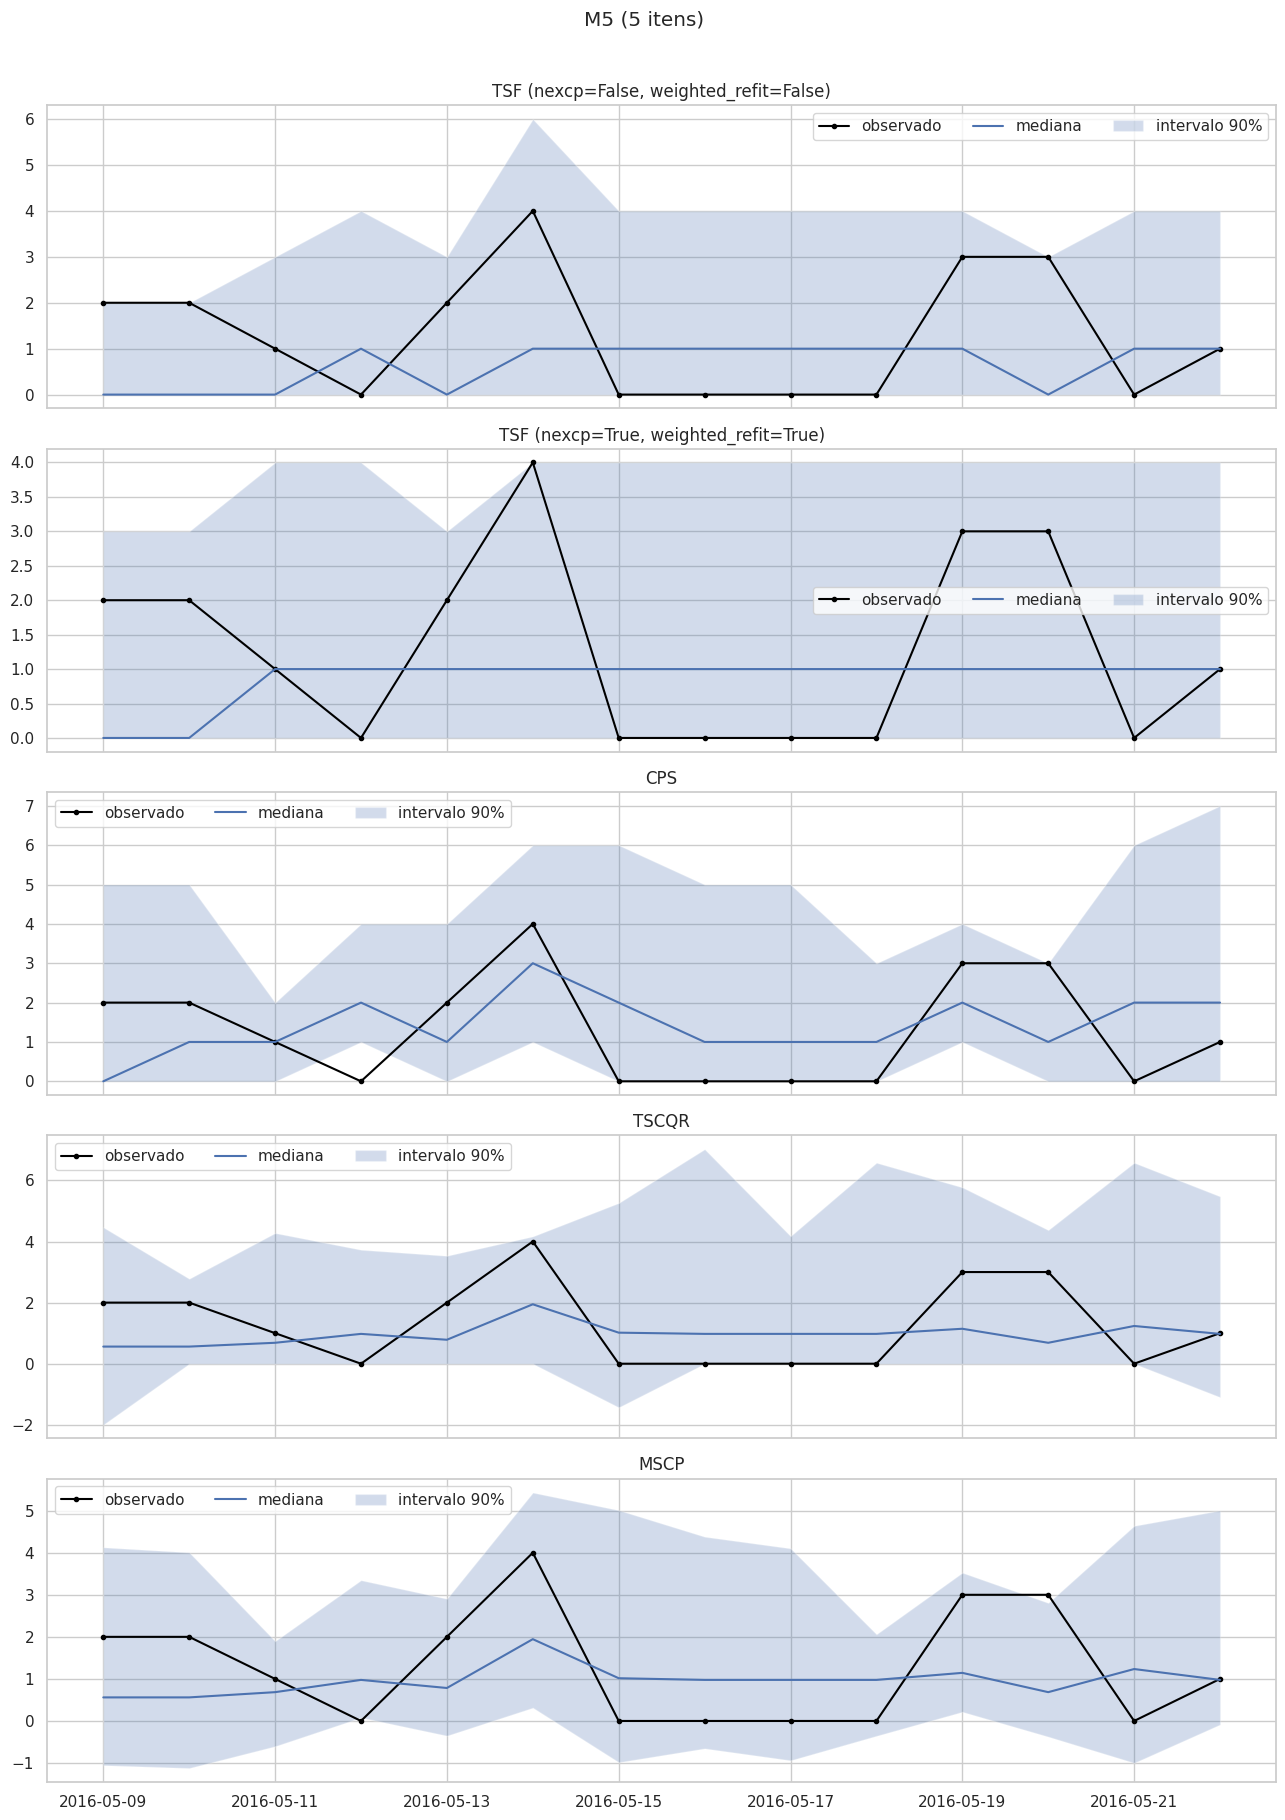

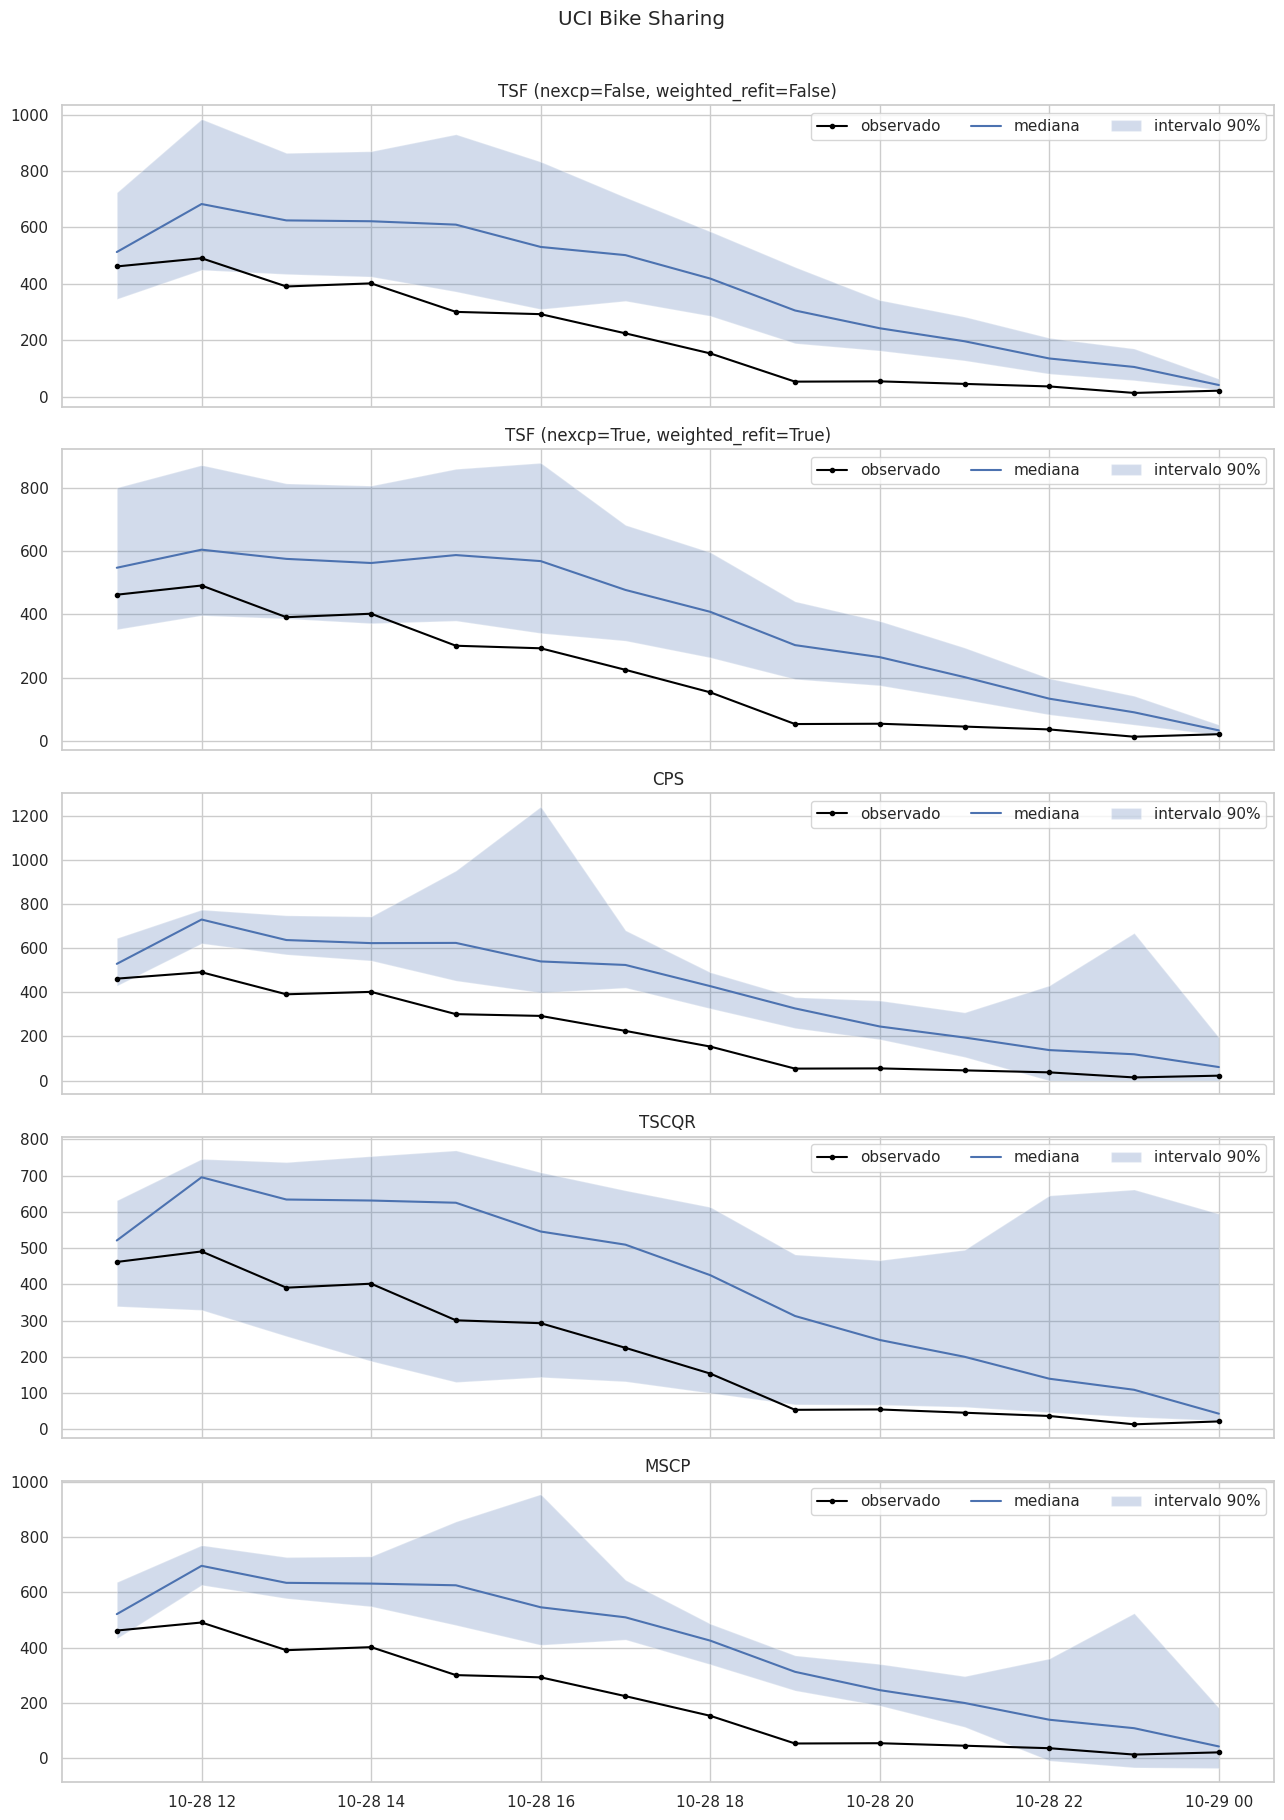

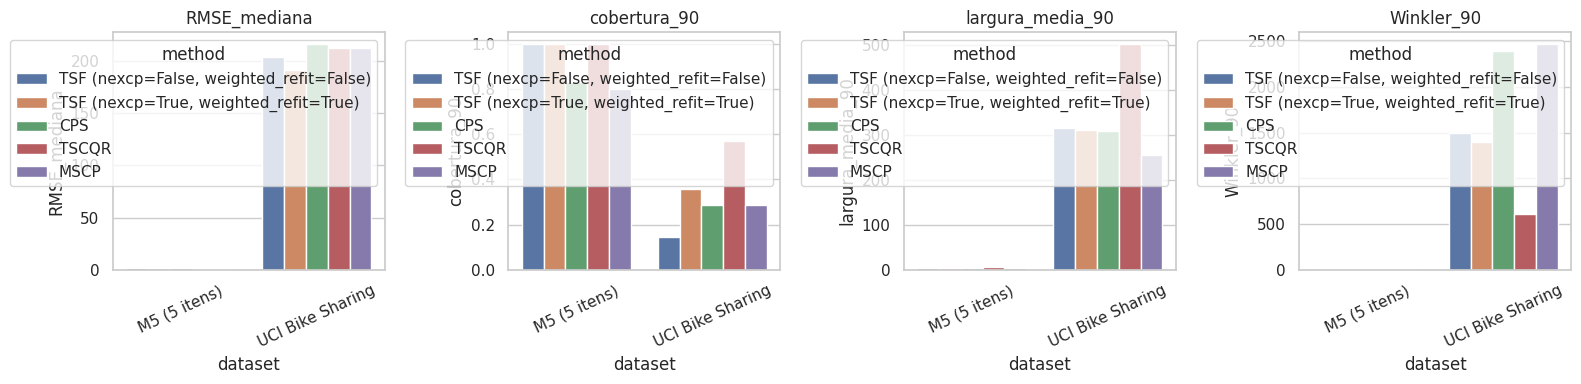

In [9]:
for dataset_name in datasets:
    plot_intervals(
        {method: predictions[(dataset_name, method)] for method in [
            "TSF (nexcp=False, weighted_refit=False)",
            "TSF (nexcp=True, weighted_refit=True)",
            "CPS", "TSCQR", "MSCP",
        ]},
        dataset_name,
    )

metric_cols = ["RMSE_mediana", "cobertura_90", "largura_media_90", "Winkler_90"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, metric in zip(axes, metric_cols):
    sns.barplot(resultados, x="dataset", y=metric, hue="method", ax=ax)
    ax.tick_params(axis="x", rotation=25); ax.set_title(metric)
plt.tight_layout()

In [10]:
def winners(frame):
    rows = []
    for dataset, part in frame.groupby("dataset"):
        target = 0.90
        rows.append({
            "dataset": dataset,
            "menor_RMSE": part.loc[part.RMSE_mediana.idxmin(), "method"],
            "cobertura_mais_próxima_90%": part.loc[(part.cobertura_90-target).abs().idxmin(), "method"],
            "menor_Winkler": part.loc[part.Winkler_90.idxmin(), "method"],
            "fit_mais_rápido": part.loc[part.fit_s.idxmin(), "method"],
        })
    return pd.DataFrame(rows)

display(winners(resultados))
print("Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.")

,dataset,menor_RMSE,cobertura_mais_próxima_90%,menor_Winkler,fit_mais_rápido
0,M5 (5 itens),TSCQR,CPS,"TSF (nexcp=False, weighted_refit=False)",MSCP
1,UCI Bike Sharing,"TSF (nexcp=True, weighted_refit=True)",TSCQR,TSCQR,"TSF (nexcp=False, weighted_refit=False)"


Leitura: cobertura isolada não premia intervalos excessivamente largos; por isso Winkler é a métrica principal de intervalo.


## Reprodutibilidade e ressalvas

- Não há geração de dados sintéticos. As URLs/fontes estão explícitas no notebook.
- Resultados dependem de hardware, versões e da janela temporal escolhida.
- M5 exige aceitar as regras da competição e autenticar o Kaggle uma única vez.
- TSF é paramétrico; CPS, TSCQR e MSCP usam calibração conformal. Nenhum método domina necessariamente em todos os critérios.